# **Project: SmartCity** | Integrated Urban Intelligence & Automated Response System


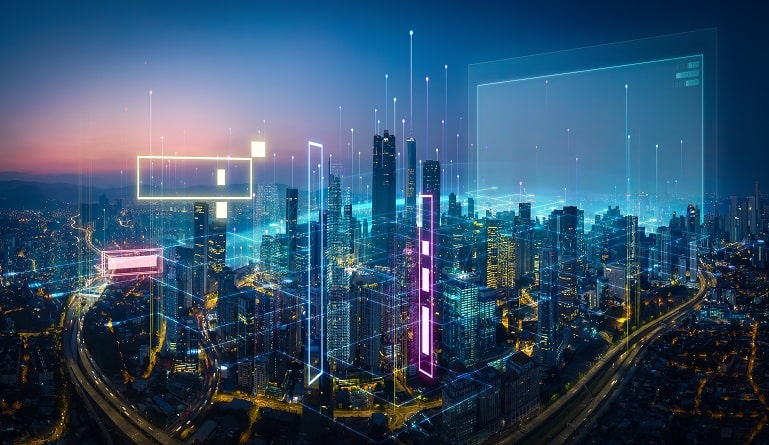

**Latar Belakang Masalah**

Urbanisasi yang cepat membawa tantangan besar bagi tata kelola kota. Masalah utama yang sering dihadapi adalah:


*   Inefisiensi Respon: Keluhan warga sering menumpuk dan lambat diproses karena sistem klasifikasi manual.
*   Kemacetan Terpusat: Kurangnya prediksi real-time yang membuat penanganan lalu lintas bersifat reaktif.
*   Pemborosan Energi: Penggunaan listrik publik (lampu jalan) yang tidak terpantau secara anomali.


*Visi Proyek: Membangun "Command Center" digital yang mengubah data mentah dari infrastruktur dan laporan warga menjadi aksi nyata yang proaktif.*

## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

## Exploratory Data Analysis

In [2]:
data_path = '/content/drive/MyDrive/Data Science/Study Case - SmartCity/data/'

# List all files in the directory
print(os.listdir(data_path))

['311_ServiceRequest_2020-present_DataDictionary_Updated_2025.xlsx']


In [3]:
xl = pd.ExcelFile('/content/drive/MyDrive/Data Science/Study Case - SmartCity/data/311_ServiceRequest_2020-present_DataDictionary_Updated_2025.xlsx')
print("Daftar Sheet yang tersedia:")
print(xl.sheet_names)

data_dictionary_path = '/content/drive/MyDrive/Data Science/Study Case - SmartCity/data/311_ServiceRequest_2020-present_DataDictionary_Updated_2025.xlsx'

Daftar Sheet yang tersedia:
['Dataset Information', 'Column Information', 'All Agencies Complaint<>Details', 'HPD Complaint<>Details', 'Dataset Revision History', 'Hidden_Frequencies', 'Hidden_Agencies', 'Hidden_DataTypes']


In [4]:
df_meta = pd.read_excel(data_dictionary_path, sheet_name='All Agencies Complaint<>Details')

# Menampilkan 5 data teratas untuk verifikasi
print(df_meta.head())

                     Agency                    Complaint Type  \
0  Department for the Aging  Case Management Agency Complaint   
1  Department for the Aging  Case Management Agency Complaint   
2  Department for the Aging                       Elder Abuse   
3  Department for the Aging                          Eviction   
4  Department for the Aging                          Eviction   

         Descriptor Additional_Details Public View    Location_Type  
0               NaN                NaN          No  Address Unknown  
1               NaN                NaN          No   Senior Address  
2               NaN                NaN          No   Senior Address  
3  Homebound Senior                NaN          No  Address Unknown  
4     Mobile Senior                NaN          No  Address Unknown  


In [5]:
file_path = '/content/drive/MyDrive/Data Science/Study Case - SmartCity/data/311_ServiceRequest_2020-present_DataDictionary_Updated_2025.xlsx'

# Kita gunakan sheet_name 'All Agencies Complaint<>Details' untuk mendapatkan data agensi yang benar
df_agencies = pd.read_excel(file_path, sheet_name='All Agencies Complaint<>Details')

# Cek apakah kolom Agency sudah muncul
print("Kolom yang tersedia:", df_agencies.columns.tolist())
display(df_agencies.head())

Kolom yang tersedia: ['Agency', 'Complaint Type', 'Descriptor', 'Additional_Details', 'Public View', 'Location_Type']


,Agency,Complaint Type,Descriptor,Additional_Details,Public View,Location_Type
0,Department for the Aging,Case Management Agency Complaint,NaN,NaN,No,Address Unknown
1,Department for the Aging,Case Management Agency Complaint,NaN,NaN,No,Senior Address
2,Department for the Aging,Elder Abuse,NaN,NaN,No,Senior Address
3,Department for the Aging,Eviction,Homebound Senior,NaN,No,Address Unknown
4,Department for the Aging,Eviction,Mobile Senior,NaN,No,Address Unknown


/tmp/ipykernel_24235/2519310679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agency_dist.values, y=agency_dist.index, palette='coolwarm')


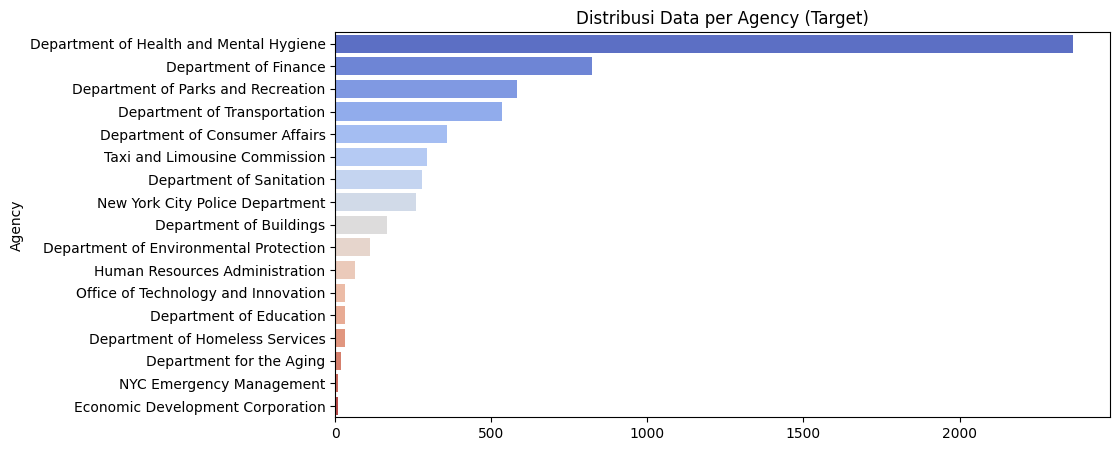


Proporsi Data (%) :
Agency
Department of Health and Mental Hygiene    39.644474
Department of Finance                      13.785008
Department of Parks and Recreation          9.793728
Department of Transportation                8.938454
Department of Consumer Affairs              6.003689
Taxi and Limousine Commission               4.930404
Department of Sanitation                    4.662083
New York City Police Department             4.326681
Department of Buildings                     2.800604
Department of Environmental Protection      1.895019
Human Resources Administration              1.056515
Office of Technology and Innovation         0.519873
Department of Education                     0.519873
Department of Homeless Services             0.503102
Department for the Aging                    0.301861
NYC Emergency Management                    0.167701
Economic Development Corporation            0.150931
Name: proportion, dtype: float64


In [6]:
# Cek distribusi target (Agency)
plt.figure(figsize=(10, 5))
agency_dist = df_agencies['Agency'].value_counts()
sns.barplot(x=agency_dist.values, y=agency_dist.index, palette='coolwarm')
plt.title('Distribusi Data per Agency (Target)')
plt.show()

print("\nProporsi Data (%) :")
print(df_agencies['Agency'].value_counts(normalize=True) * 100)

In [7]:
# Cek apakah ada string "N/A" yang bukan merupakan Null asli
na_strings = df_agencies[df_agencies['Descriptor'].astype(str).str.contains('N/A|n/a|None', na=False)]
print(f"\nJumlah baris dengan teks 'N/A' di Descriptor: {len(na_strings)}")

# Cek 10 Descriptor terpendek (biasanya kurang informatif)
print("\nContoh Descriptor terpendek:")
print(df_agencies['Descriptor'].astype(str).unique()[:10])


Jumlah baris dengan teks 'N/A' di Descriptor: 1

Contoh Descriptor terpendek:
['nan' 'Homebound Senior' 'Mobile Senior' 'Apartment' 'House'
 'Not Closed/Sealed' 'Zoning Violation' 'Billboard' 'Flexible Fabric'
 'Poster']


### Analisis Lokasi (Location Type)

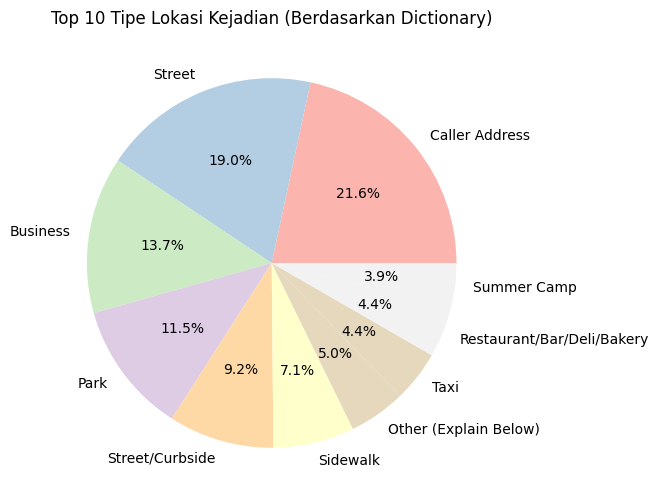

In [8]:
plt.figure(figsize=(10, 6))
df_meta['Location_Type'].value_counts().head(10).plot(
    kind='pie',
    autopct='%1.1f%%',
    cmap='Pastel1'
)

plt.title('Top 10 Tipe Lokasi Kejadian (Berdasarkan Dictionary)')
plt.ylabel('')
plt.show()

### All Agencies Complaint<>Details

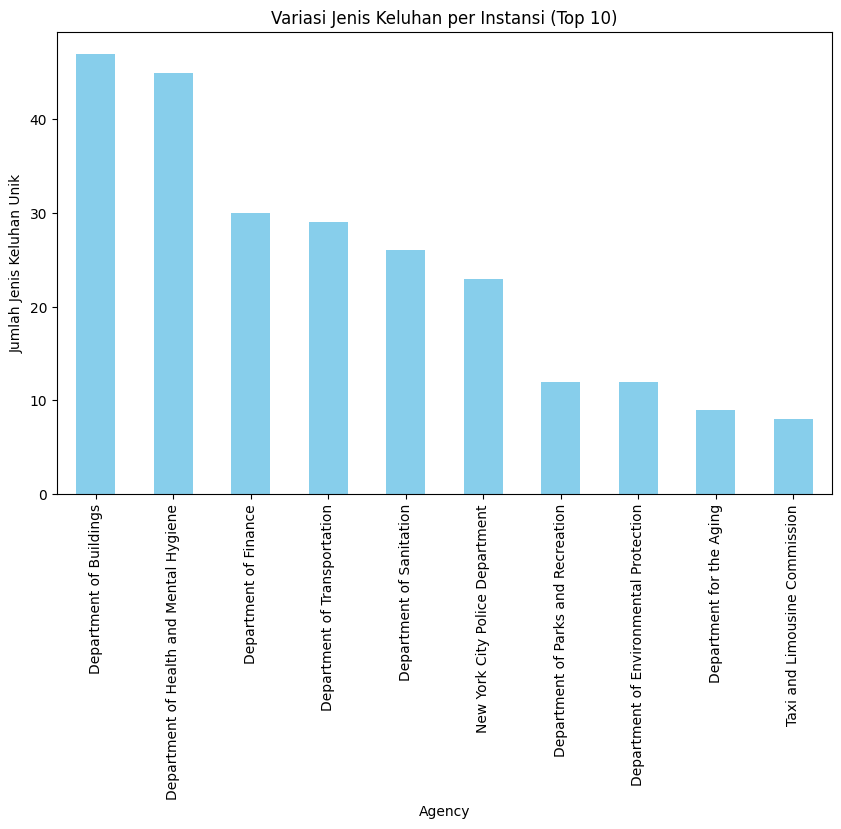

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load sheet All Agencies from the data dictionary using pd.read_excel
df_meta = pd.read_excel(data_dictionary_path, sheet_name='All Agencies Complaint<>Details')

# Cek jumlah jenis keluhan unik per Agency
agency_counts = df_meta.groupby('Agency')['Complaint Type'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
agency_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Variasi Jenis Keluhan per Instansi (Top 10)')
plt.ylabel('Jumlah Jenis Keluhan Unik')
plt.show()

### Analisis Spesifik: Jenis Keluhan Terbanyak (Complaint Type)

/tmp/ipykernel_24235/691646520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_complaints.values, y=top_complaints.index, palette='magma')


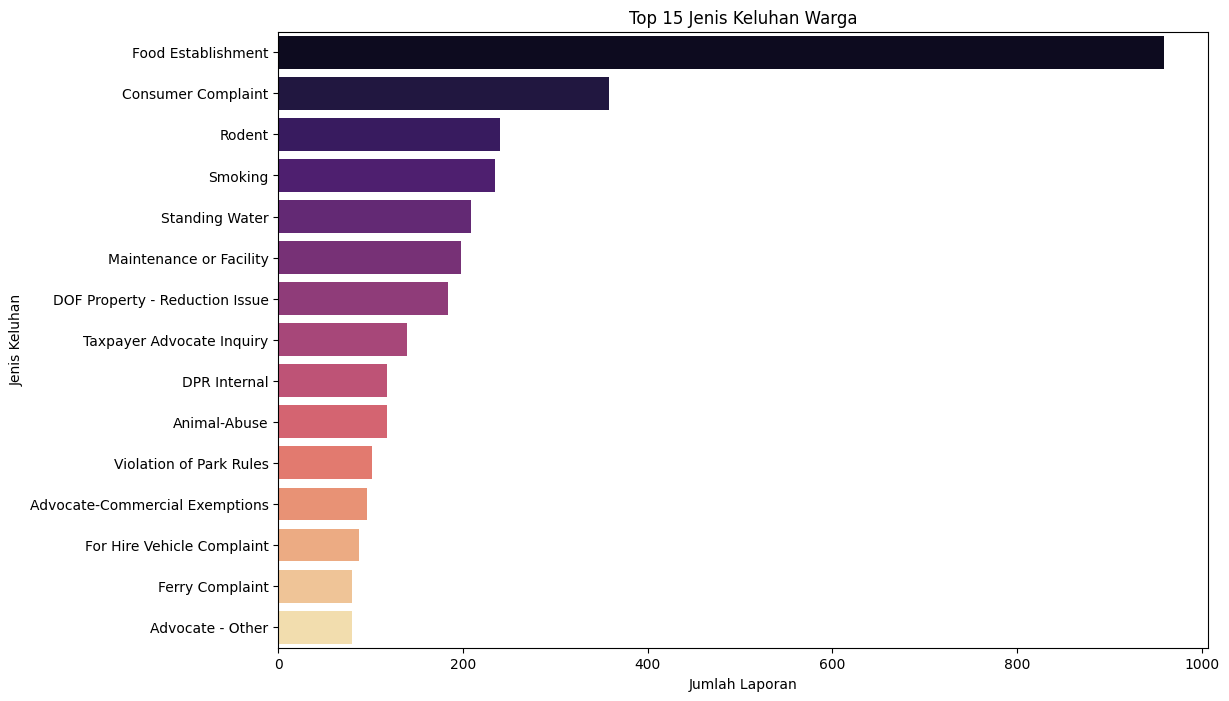

In [10]:
plt.figure(figsize=(12, 8))
top_complaints = df_meta['Complaint Type'].value_counts().head(15)
sns.barplot(x=top_complaints.values, y=top_complaints.index, palette='magma')

plt.title('Top 15 Jenis Keluhan Warga')
plt.xlabel('Jumlah Laporan')
plt.ylabel('Jenis Keluhan')
plt.show()

### Analisis Hubungan: Agency vs Tipe Lokasi

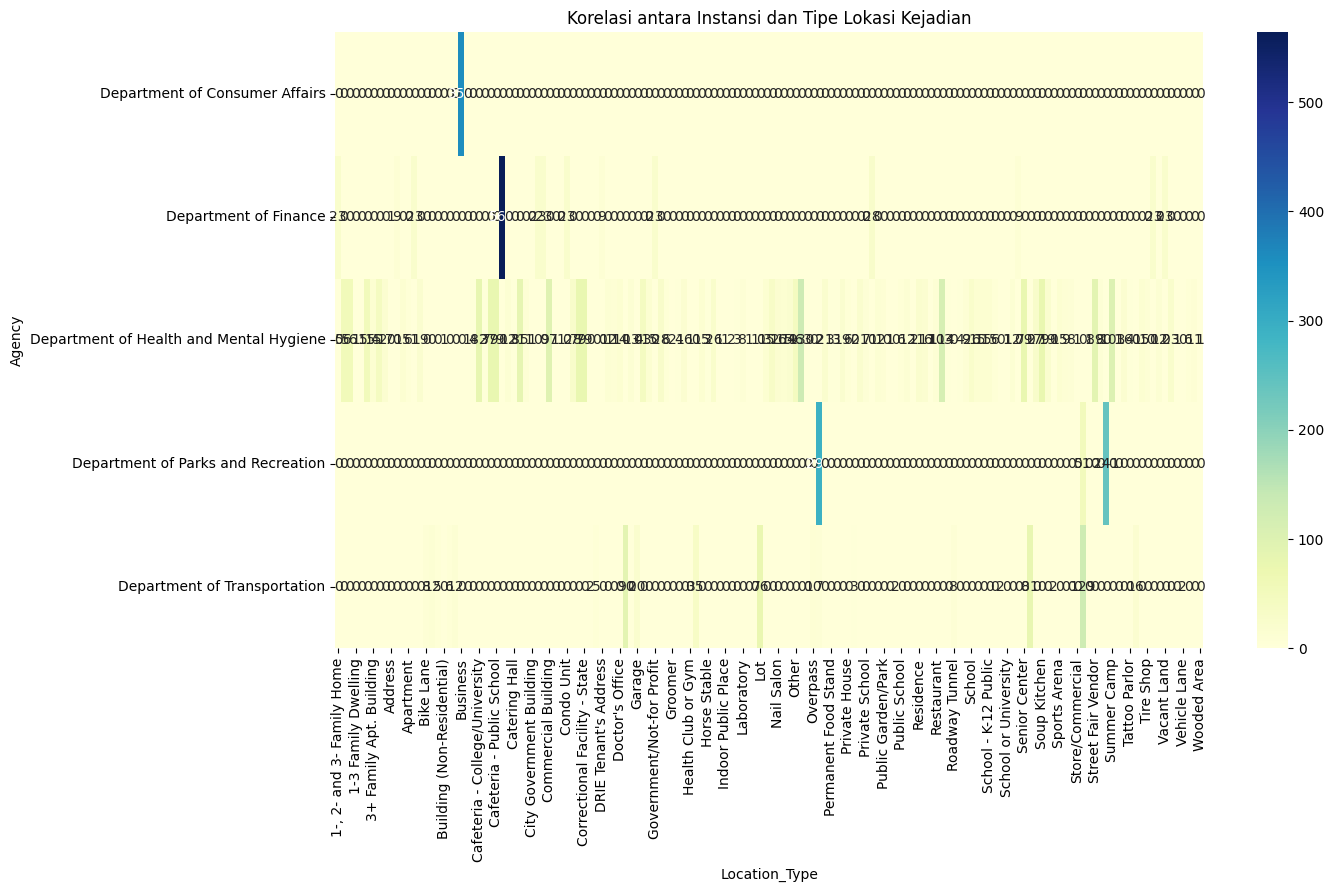

In [11]:
# Membuat crosstab antara Agency dan Location Type (Top 5 Agency saja agar rapi)
top_5_agencies = df_meta['Agency'].value_counts().head(5).index
df_filtered = df_meta[df_meta['Agency'].isin(top_5_agencies)]

ct = pd.crosstab(df_filtered['Agency'], df_filtered['Location_Type'])

# Visualisasi dengan Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Korelasi antara Instansi dan Tipe Lokasi Kejadian')
plt.show()

### Analisis Kesiapan NLP: Distribusi Panjang Teks (Descriptor)

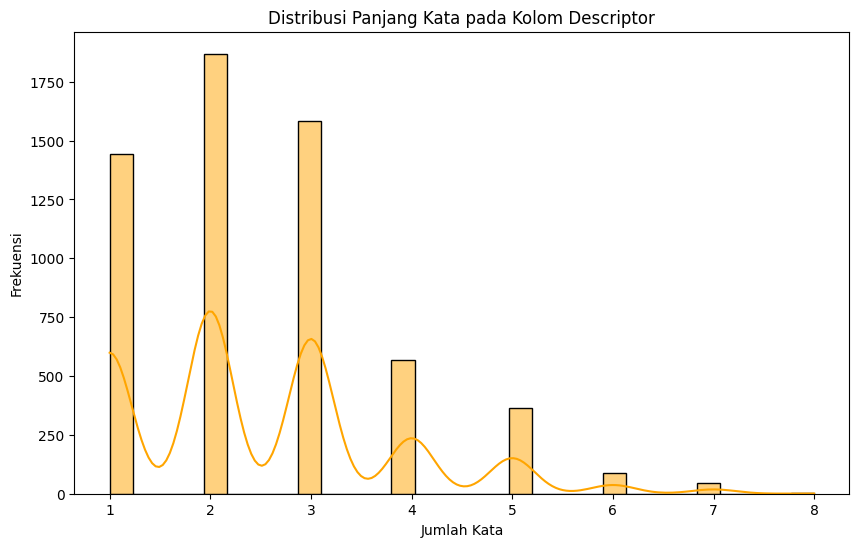

In [12]:
# Menghitung jumlah kata dalam setiap deskripsi
df_meta['descriptor_len'] = df_meta['Descriptor'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_meta['descriptor_len'], bins=30, kde=True, color='orange')
plt.title('Distribusi Panjang Kata pada Kolom Descriptor')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.show()

## Pre Processing

### Transformasi Target Variable (Agency)

In [13]:
# 1. Bersihkan data kosong di kolom target
df_agencies = df_agencies.dropna(subset=['Agency'])

# 2. Inisialisasi LabelEncoder
le = LabelEncoder()

# 3. Transformasi Agency menjadi angka
df_agencies['agency_label'] = le.fit_transform(df_agencies['Agency'])

# 4. Simpan mapping (Penting untuk Dashboard nanti)
agency_mapping = dict(zip(le.transform(le.classes_), le.classes_))

print("Contoh Mapping (ID -> Nama Instansi):")
print(list(agency_mapping.items())[:5])

Contoh Mapping (ID -> Nama Instansi):
[(np.int64(0), 'Department for the Aging'), (np.int64(1), 'Department of Buildings'), (np.int64(2), 'Department of Consumer Affairs'), (np.int64(3), 'Department of Education'), (np.int64(4), 'Department of Environmental Protection')]


In [14]:
df_asli = pd.read_excel('/content/drive/MyDrive/Data Science/Study Case - SmartCity/data/311_ServiceRequest_2020-present_DataDictionary_Updated_2025.xlsx')

# Display the first few rows to confirm it's loaded correctly
display(df_asli.head())

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


### Handling Missing Values

In [15]:
# 1. Cek info umum dan tipe data
print("--- Info Struktur Data ---")
print(df_agencies.info())

# 2. Cek Missing Values (NaN)
print("\n--- Jumlah Missing Values per Kolom ---")
missing_data = df_agencies.isnull().sum()
print(missing_data[missing_data > 0])

# 3. Cek Duplikat
print(f"\nJumlah Baris Duplikat: {df_agencies.duplicated().sum()}")

--- Info Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5963 entries, 0 to 5962
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Agency              5963 non-null   object
 1   Complaint Type      5963 non-null   object
 2   Descriptor          5861 non-null   object
 3   Additional_Details  3986 non-null   object
 4   Public View         5963 non-null   object
 5   Location_Type       5883 non-null   object
 6   agency_label        5963 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 326.2+ KB
None

--- Jumlah Missing Values per Kolom ---
Descriptor             102
Additional_Details    1977
Location_Type           80
dtype: int64

Jumlah Baris Duplikat: 165


In [16]:
# Mengisi N/A dengan teks agar TF-IDF bisa memprosesnya
df_agencies['Descriptor'] = df_agencies['Descriptor'].fillna('no description')
df_agencies['Complaint Type'] = df_agencies['Complaint Type'].fillna('no complaint type')

# Menghapus baris yang Agency-nya kosong (jika ada)
df_agencies = df_agencies.dropna(subset=['Agency'])

### Label Encoding (Ubah Target ke Angka)

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_agencies['agency_id'] = le.fit_transform(df_agencies['Agency'])

# Cek hasil encoding
print("Mapping Agency ke ID:")
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(list(mapping.items())[:5]) # Tampilkan 5 pertama

Mapping Agency ke ID:
[('Department for the Aging', np.int64(0)), ('Department of Buildings', np.int64(1)), ('Department of Consumer Affairs', np.int64(2)), ('Department of Education', np.int64(3)), ('Department of Environmental Protection', np.int64(4))]


### Text Vectorization (TF-IDF)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1, 2))

# Transformasi kolom Descriptor
X_features = tfidf.fit_transform(df_agencies['Descriptor'])

print(f"Bentuk matrix fitur: {X_features.shape}")

Bentuk matrix fitur: (5963, 2000)


## Modelling

### Train & Test

In [19]:
# Kita bagi data asli menjadi Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    df_agencies['agency_id'],
    test_size=0.2,
    random_state=42,
    stratify=df_agencies['agency_id'] # Penting agar distribusi Agency merata di kedua set
)

print(f"Sebelum SMOTE - Data Training: {X_train.shape[0]} baris")

# Ini untuk menyeimbangkan instansi yang datanya sedikit (minoritas)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Setelah SMOTE - Data Training: {len(y_train_res)} baris")
print(f"Data Testing (Tetap Asli): {X_test.shape[0]} baris")

Sebelum SMOTE - Data Training: 4770 baris
Setelah SMOTE - Data Training: 32147 baris
Data Testing (Tetap Asli): 1193 baris


In [20]:
# Inisialisasi Model
model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    random_state=42
)

# Proses Training
print("Sedang melatih model... Mohon tunggu sebentar.")
model_xgb.fit(X_train_res, y_train_res)
print("Training selesai!")

Sedang melatih model... Mohon tunggu sebentar.
Training selesai!


In [21]:
# Prediksi data testing
y_pred = model_xgb.predict(X_test)

# Menampilkan hasil
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nLaporan Klasifikasi Per Agency:")
# target_names menggunakan nama Agency asli dari LabelEncoder sebelumnya
print(classification_report(y_test, y_pred, target_names=le.classes_))

Akurasi Model: 87.85%

Laporan Klasifikasi Per Agency:
                                         precision    recall  f1-score   support

               Department for the Aging       0.12      1.00      0.22         3
                Department of Buildings       0.82      0.70      0.75        33
         Department of Consumer Affairs       0.99      0.92      0.95        72
                Department of Education       0.75      0.50      0.60         6
 Department of Environmental Protection       0.65      0.48      0.55        23
                  Department of Finance       1.00      0.92      0.96       164
Department of Health and Mental Hygiene       0.85      0.95      0.90       473
        Department of Homeless Services       1.00      0.33      0.50         6
     Department of Parks and Recreation       0.96      0.93      0.95       117
               Department of Sanitation       0.77      0.71      0.74        56
           Department of Transportation       0.88   

### Evaluasi

In [22]:
# Hitung akurasi pada data training
y_train_pred = model_xgb.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Hitung akurasi pada data testing
test_acc = accuracy_score(y_test, y_pred)

print(f"--- Evaluasi Akurasi ---")
print(f"Akurasi Data Training : {train_acc * 100:.2f}%")
print(f"Akurasi Data Testing  : {test_acc * 100:.2f}%")

--- Evaluasi Akurasi ---
Akurasi Data Training : 93.44%
Akurasi Data Testing  : 87.85%


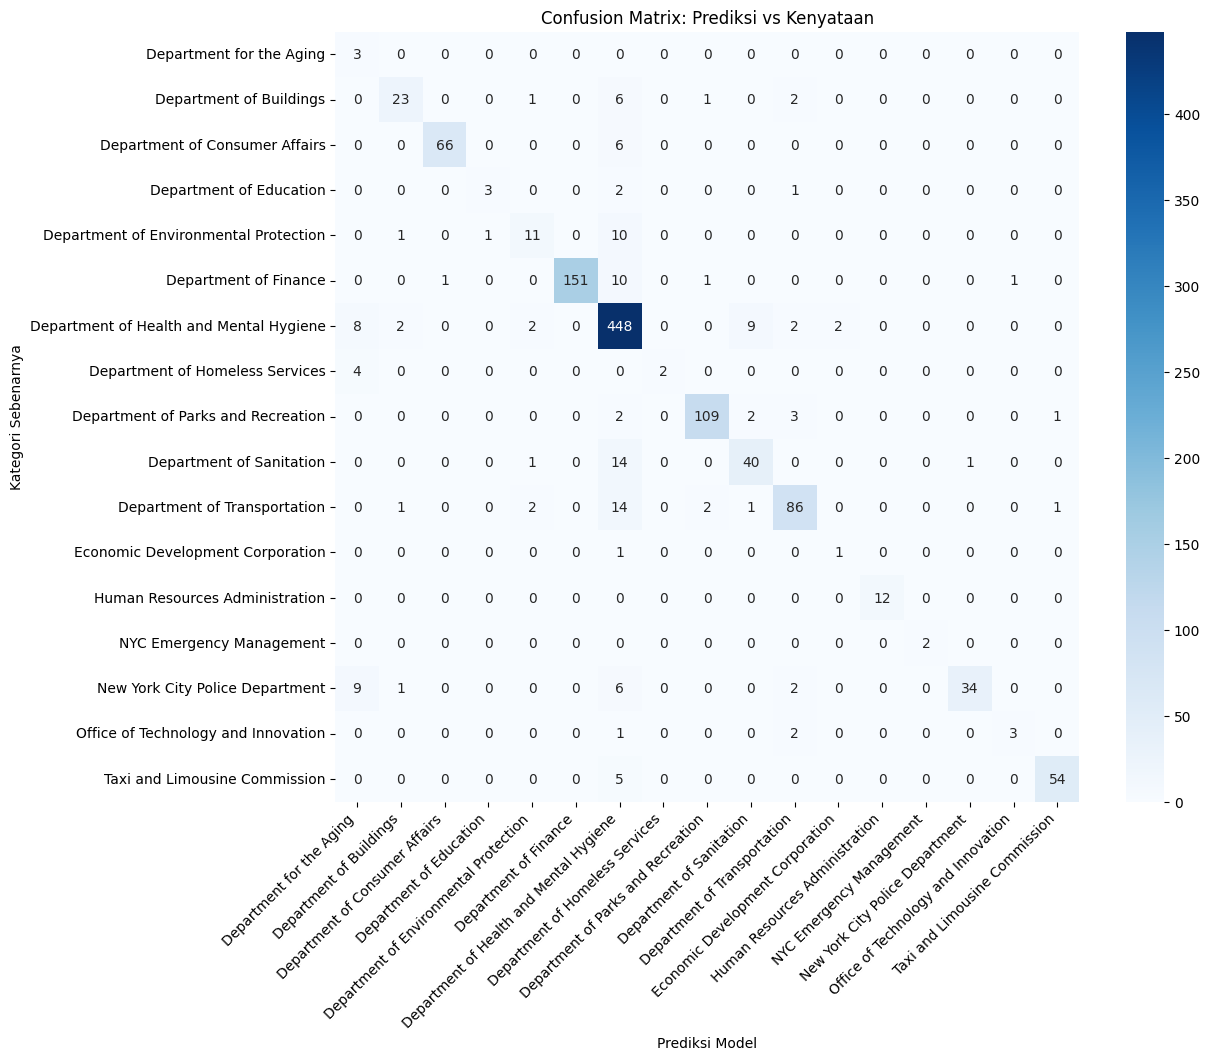

In [23]:
# Membuat matriks
cm = confusion_matrix(y_test, y_pred)

# Visualisasi dengan Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Confusion Matrix: Prediksi vs Kenyataan')
plt.xlabel('Prediksi Model')
plt.ylabel('Kategori Sebenarnya')
plt.xticks(rotation=45, ha='right')
plt.show()

## Real Testing

In [24]:
def tes_keluhan_baru(teks):
    # 1. Preprocessing sederhana (sama dengan saat training)
    teks_clean = [teks.lower()]

    # 2. Transformasi ke TF-IDF
    teks_tfidf = tfidf.transform(teks_clean)

    # 3. Prediksi
    pred_id = model_xgb.predict(teks_tfidf)[0]
    probabilitas = np.max(model_xgb.predict_proba(teks_tfidf)) * 100

    # 4. Decode label
    nama_agency = le.inverse_transform([pred_id])[0]

    print(f"--- Hasil Prediksi AI ---")
    print(f"Keluhan   : '{teks}'")
    print(f"Target    : {nama_agency}")
    print(f"Keyakinan : {probabilitas:.2f}%")

# COBA DISINI: Ganti kalimat di bawah dengan masalah kota apa saja
tes_keluhan_baru("There is a loud party next door and I can't sleep")

--- Hasil Prediksi AI ---
Keluhan   : 'There is a loud party next door and I can't sleep'
Target    : New York City Police Department
Keyakinan : 90.05%


## Menyimpan Model

In [25]:
import joblib

joblib.dump(model_xgb, '/content/drive/MyDrive/Data Science/Study Case - SmartCity/models/smart_city_xgb_model.pkl')
joblib.dump(tfidf, '/content/drive/MyDrive/Data Science/Study Case - SmartCity/models/tfidf_vectorizer.pkl')
joblib.dump(le, '/content/drive/MyDrive/Data Science/Study Case - SmartCity/models/label_encoder.pkl')

print("Semua artefak model berhasil diamankan di Google Drive!")

Semua artefak model berhasil diamankan di Google Drive!
